In [ ]:
%pip install CatBoost

In [ ]:
%pip install Optuna

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from pathlib import Path
import sys
import itertools
import optuna
from catboost import CatBoostClassifier
from sklearn.metrics import average_precision_score, roc_auc_score
from metric import pr_curve, precision_at_recall

# EDA

## Общий обзор

Для начала выведем общую информацию о имеющихся данных, посмторим на распределние целевой переменной

In [2]:
train = pd.read_csv('train.csv')
test = pd.read_csv('test.csv')
events = pd.read_csv('events.csv')

print(train.shape)
display(train.head())
print(train.dtypes)

(11091, 5)


,cookie_id,cookie_created_at,window_start_ts,window_end_ts,target
0,ck_54a059eb7d3ea68b,2025-11-21 09:30:41,2026-04-06,2026-04-07,0
1,ck_7e4de46eeab82974,2025-09-23 10:10:24,2026-04-06,2026-04-07,0
2,ck_9320229ef6304522,2026-03-04 00:08:02,2026-04-06,2026-04-07,0
3,ck_30ccd25bc1714ed9,2026-04-05 10:52:40,2026-04-06,2026-04-07,0
4,ck_a77c5f05948cdeef,2026-01-01 03:54:35,2026-04-06,2026-04-07,0


cookie_id              str
cookie_created_at      str
window_start_ts        str
window_end_ts          str
target               int64
dtype: object


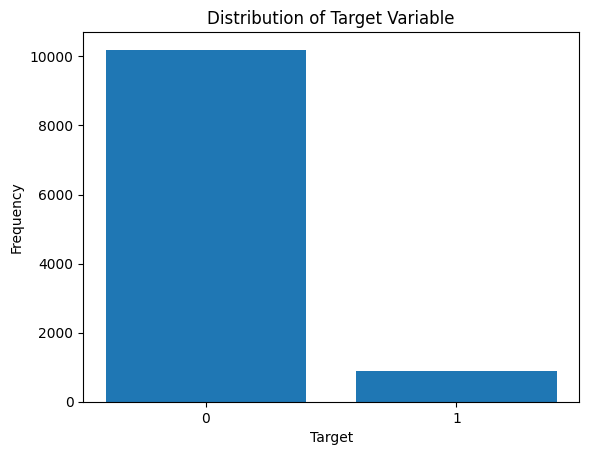

In [3]:
plt.bar(train["target"].value_counts().index, train["target"].value_counts().values)

plt.xlabel("Target")
plt.ylabel("Frequency")
plt.title("Distribution of Target Variable")

plt.xticks([0, 1])
plt.show()

In [4]:
train.isna().sum().sum()

np.int64(0)

Как видно из графиков, классы не сбалансированы

Теперь посмторим на данные из events

In [5]:
print(events.shape)
print(events.head())
print(events.dtypes)

(328905, 14)
             cookie_id             event_ts  eid           event_name  \
0  ck_5efbea1befdefe1b  2026-04-26 09:11:24  200            item_view   
1  ck_c4ca1434f3778f1d  2026-04-20 14:04:31  100  search_results_view   
2  ck_d274382b19488771  2026-04-13 12:02:56  200            item_view   
3  ck_fbbed2ff14944ce9  2026-04-08 06:12:14  100  search_results_view   
4  ck_56cc15c7c634cb9f  2026-04-12 17:16:05  100  search_results_view   

  platform                                         user_agent    item_id  \
0  desktop  Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...  1027450.0   
1      web  Mozilla/5.0 (Windows NT 10.0; Win64; x64; rv:1...        NaN   
2      WEB  Mozilla/5.0 (Windows NT 10.0; Win64; x64) Appl...  1048743.0   
3      web  Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...        NaN   
4      WEB  Mozilla/5.0 (Macintosh; Intel Mac OS X 10_15_7...        NaN   

       item_category    item_location seller_type    search_query  \
0        elektronika  

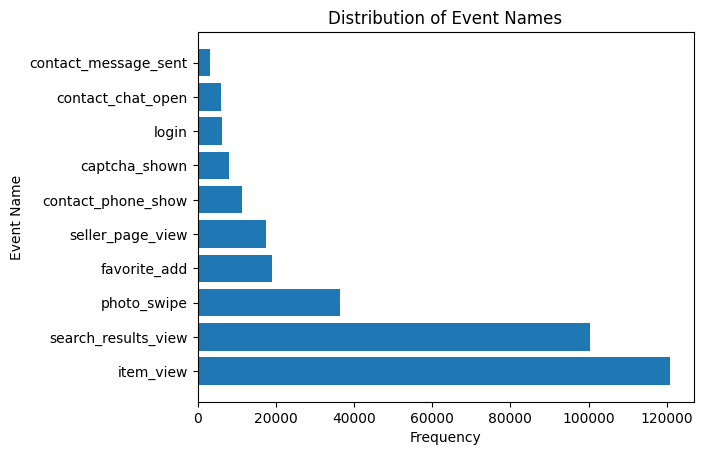

In [6]:
event_counts = events["event_name"].value_counts()
plt.barh(event_counts.index, event_counts.values)
plt.xlabel("Frequency")
plt.ylabel("Event Name")
plt.title("Distribution of Event Names")
plt.show()

In [7]:
print('Кук в журнале:', events.cookie_id.nunique())
print('Период событий:', events.event_ts.min(), '—', events.event_ts.max())
print('Дубликаты целых строк:', events.duplicated().sum())

Кук в журнале: 16000
Период событий: 2026-04-06 00:02:57 — 2026-04-26 23:59:50
Дубликаты целых строк: 4863


## Дубликаты

В events достаточно много дубликатов, но нужно убедиться, что это действительно дубликаты, а не разные куки с похожими параметриами

In [8]:
events.duplicated().sum()

np.int64(4863)

In [9]:
duplicates = events[events.duplicated(keep=False)]

duplicates.sort_values(by="cookie_id", inplace=True)
duplicates.head()

,cookie_id,event_ts,eid,event_name,platform,user_agent,item_id,item_category,item_location,seller_type,search_query,search_page,pointer_x,pointer_y
37283,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
141860,ck_0027b5d4107d65d8,2026-04-26 05:22:48,300,contact_phone_show,android,Mozilla/5.0 (Linux; Android 14; Redmi Note 11)...,1043647.0,elektronika,krasnoyarsk,private,NaN,NaN,NaN,NaN
321075,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
314150,ck_0027ba644f9ae2cd,2026-04-22 17:06:55,200,item_view,ANDROID,Mozilla/5.0 (Linux; Android 11; Pixel 6) Apple...,1036126.0,kvartiry_prodazha,samara,pro,NaN,NaN,NaN,NaN
10173,ck_0032c08d8987d0ad,2026-04-10 18:13:05,210,photo_swipe,android,Mozilla/5.0 (Linux; Android 14; SM-G991B) Appl...,1051179.0,NaN,moskva,pro,NaN,NaN,NaN,NaN


Полные дубликаты совпадают по всем столбцам. Это указывает на повторную запись одной и той же строки, но по этим данным нельзя установить причину. В этом анализе удаляем только полные дубликаты и отдельно проверяем их количество перед расчётом признаков.

In [10]:
events = events.drop_duplicates()

events.duplicated().sum()

np.int64(0)

## Корректировка 'platform'

In [11]:
events.platform.unique()

<StringArray>
['desktop',     'web',     'WEB',     'Web', 'Android',     'IOS', 'ANDROID',
 'android',     'ios',     'iOS',  'iphone']
Length: 11, dtype: str

Как видно, многие плафтормы потворяются, отличаясь лишь регистром (Например 'WEB', 'Web', 'web'). Их можно привести к единому виду

In [12]:
events["platform"] = events["platform"].str.lower()

<Axes: ylabel='platform'>

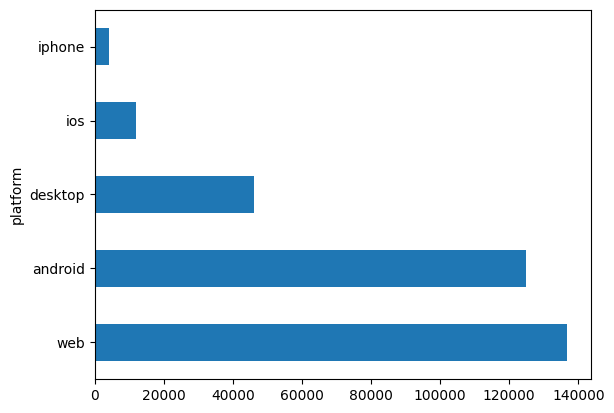

In [13]:
events['platform'].value_counts().plot(kind='barh')

## Сопоставление событий с суточными окнами

In [14]:
def attach_window_and_filter(events_df, meta):
    bounds = meta[['cookie_id', 'window_start_ts', 'window_end_ts']].copy()
    part = events_df.merge(bounds, on='cookie_id', how='inner', validate='many_to_one')

    part['event_ts'] = pd.to_datetime(part['event_ts'])
    part['window_start_ts'] = pd.to_datetime(part['window_start_ts'])
    part['window_end_ts'] = pd.to_datetime(part['window_end_ts'])

    in_window = (
        part['event_ts'].ge(part['window_start_ts']) &
        part['event_ts'].lt(part['window_end_ts'])
    )
    return part.loc[in_window].copy()

ev_train = attach_window_and_filter(events, train)
ev_test = attach_window_and_filter(events, test)
print(f'Событий train внутри окон: {len(ev_train)}')
print(f'Событий test внутри окон: {len(ev_test)}')


Событий train внутри окон: 195484
Событий test внутри окон: 88349


## Распределение активностей по классам

In [ ]:
events_target = ev_train.merge(
    train[['cookie_id', 'target']],
    on='cookie_id',
    how='inner',
    validate='many_to_one'
)

cookie_events = events_target[['cookie_id', 'target', 'event_name']].drop_duplicates()
action_share = (
    cookie_events.groupby(['target', 'event_name'])['cookie_id']
    .nunique()
    .div(train.groupby('target')['cookie_id'].nunique(), level='target')
    .reset_index(name='share')
)
action_share['share'] *= 100


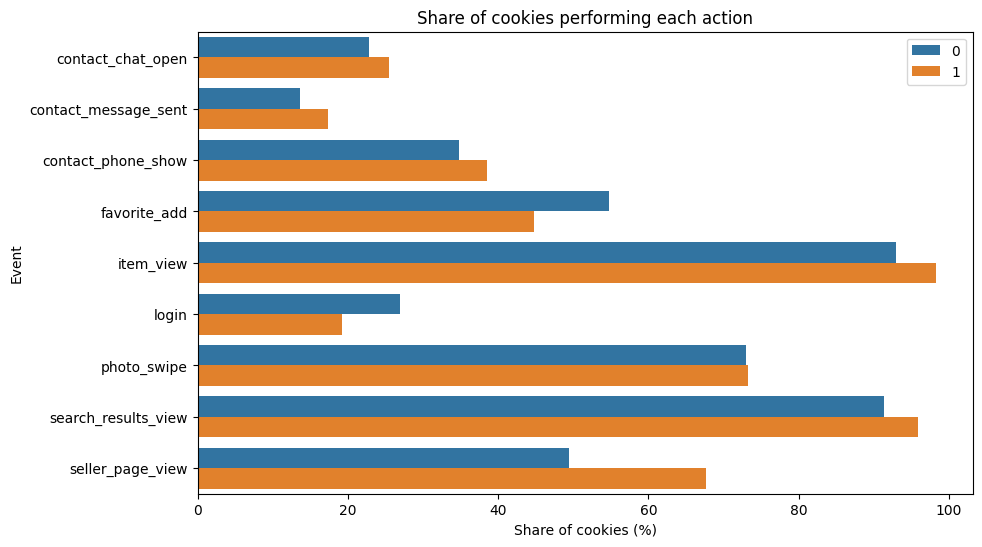

In [16]:
plt.figure(figsize=(10, 6))

sns.barplot(data=action_share, x="share", y="event_name", hue="target")

plt.xlabel("Share of cookies (%)")
plt.ylabel("Event")
plt.title("Share of cookies performing each action")
plt.legend()
plt.show()

## Расапределение платформ по классам

In [17]:
platform_share = (
    events_target.assign(platform=events_target['platform'].fillna('неизвестно'))
    .drop_duplicates(['cookie_id', 'target', 'platform'])
    .groupby(['target', 'platform'])['cookie_id'].nunique()
    .div(train.groupby('target')['cookie_id'].nunique(), level='target')
    .reset_index(name='share')
)
platform_share['share'] *= 100


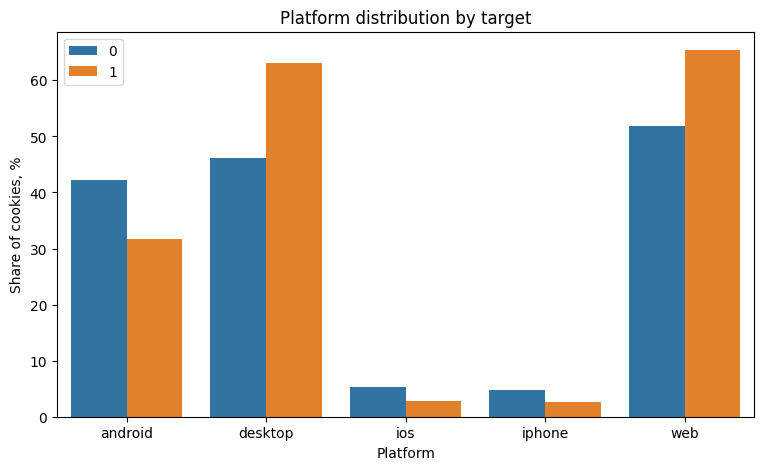

In [18]:
plt.figure(figsize=(9, 5))

sns.barplot(data=platform_share, x="platform", y="share", hue="target")

plt.xlabel("Platform")
plt.ylabel("Share of cookies, %")
plt.title("Platform distribution by target")
plt.legend()
plt.show()

## Распределение продовцов по классам

In [19]:
seller_share = (
    events_target.assign(seller_type=events_target['seller_type'].fillna('неизвестно'))
    .drop_duplicates(['cookie_id', 'target', 'seller_type'])
    .groupby(['target', 'seller_type'])['cookie_id'].nunique()
    .div(train.groupby('target')['cookie_id'].nunique(), level='target')
    .reset_index(name='share')
)
seller_share['share'] *= 100


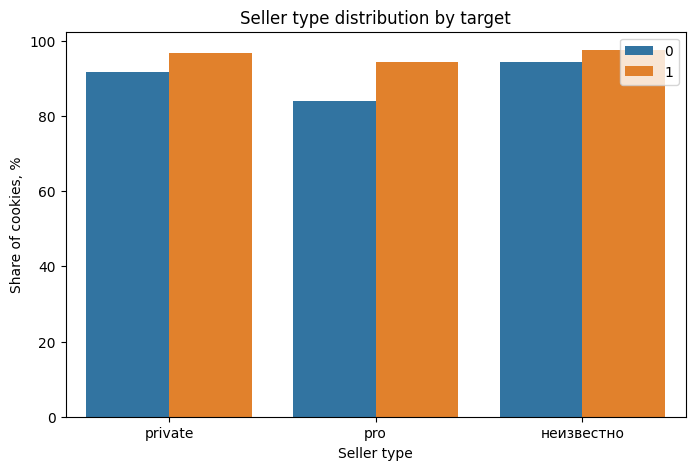

In [20]:
plt.figure(figsize=(8, 5))

sns.barplot(data=seller_share, x="seller_type", y="share", hue="target")

plt.xlabel("Seller type")
plt.ylabel("Share of cookies, %")
plt.title("Seller type distribution by target")
plt.legend()
plt.show()

## Проверки данных перед анализом признаков

Проверим уникальность cookie, пересечение train/test, длительность окон, наличие событий в окнах и пропуски. Все поведенческие сравнения ниже используют только `ev_train` — события внутри окна наблюдения.

In [ ]:
print('Строк в train , уникальных cookie:', len(train), train['cookie_id'].nunique())
print('Строк в test , уникальных cookie:', len(test), test['cookie_id'].nunique())
print('Пересечение cookie между train и test:', train['cookie_id'].isin(test['cookie_id']).sum())

Строк в train , уникальных cookie: 11091 11091
Строк в test , уникальных cookie: 4909 4909
Пересечение cookie между train и test: 0


## Ритм активности в течение суток

Считаем события каждого часа отдельно для каждой cookie, а затем усредняем внутри класса. Так более активные cookie не определяют график в одиночку.

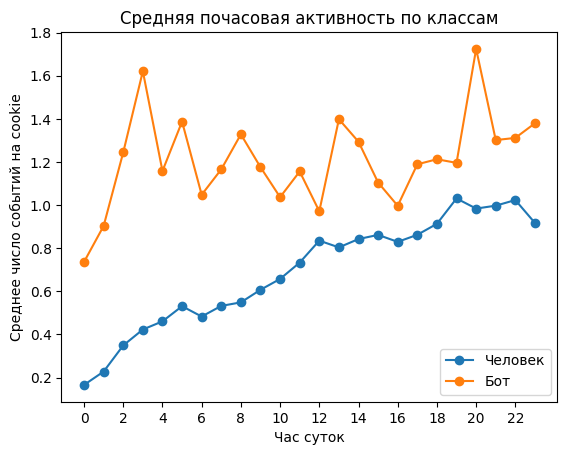

In [22]:
hourly = events_target.copy()
hourly['hour'] = hourly['event_ts'].dt.hour

hourly_cookie = (
    hourly.groupby(['cookie_id', 'target', 'hour']).size()
    .unstack('hour', fill_value=0)
    .reindex(columns=range(24), fill_value=0)
)
hourly_mean = hourly_cookie.groupby(level='target').mean()

for target, row in hourly_mean.iterrows():
    plt.plot(range(24), row, marker='o', label='Бот' if target == 1 else 'Человек')

plt.xlabel('Час суток')
plt.ylabel('Среднее число событий на cookie')
plt.title('Средняя почасовая активность по классам')
plt.xticks(range(0, 24, 2))
plt.legend()
plt.show()


## Разнообразие поведения

Для каждой cookie посчитаем число уникальных типов действий, объявлений, категорий, локаций и поисковых запросов в окне. Пропуски не считаются отдельным значением.

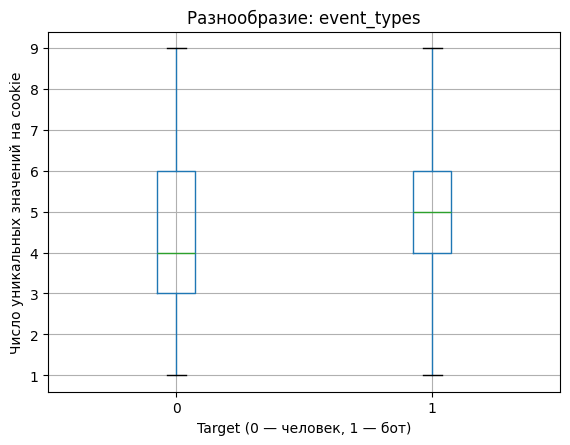

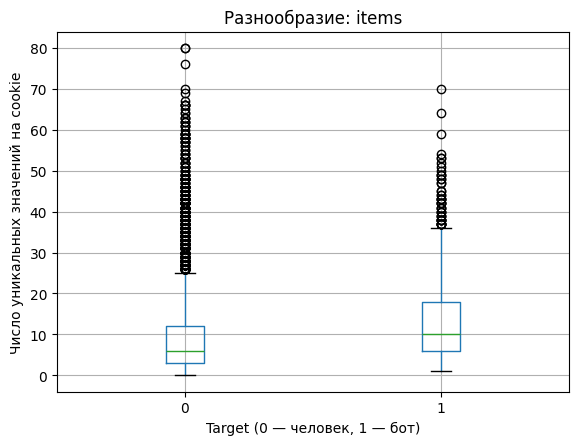

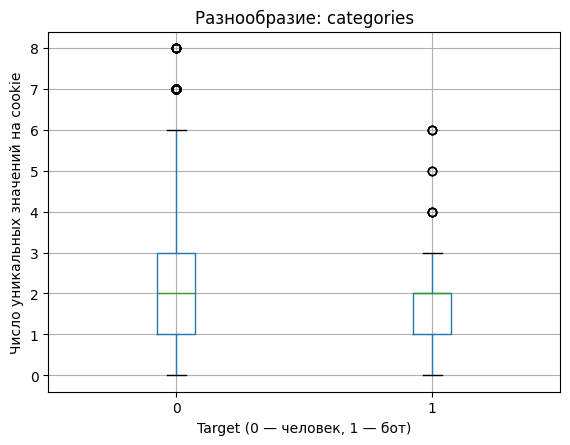

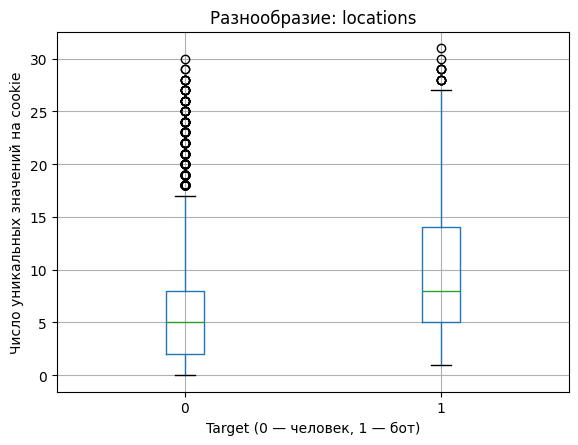

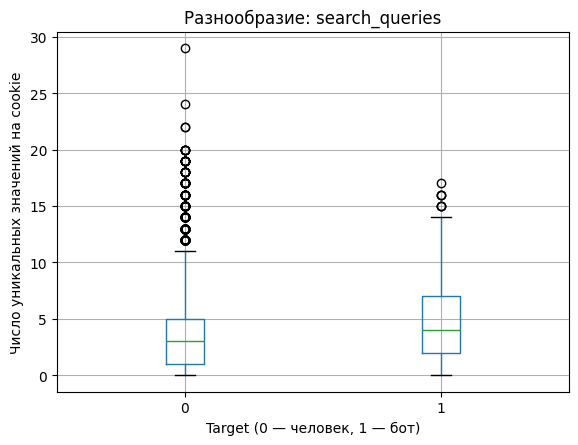

In [23]:
diversity = events_target.groupby(['cookie_id', 'target']).agg(
    event_types=('event_name', 'nunique'),
    items=('item_id', 'nunique'),
    categories=('item_category', 'nunique'),
    locations=('item_location', 'nunique'),
    search_queries=('search_query', 'nunique')
).reset_index()
diversity = train[['cookie_id', 'target']].merge(diversity, on=['cookie_id', 'target'], how='left')
diversity[['event_types', 'items', 'categories', 'locations', 'search_queries']] = diversity[['event_types', 'items', 'categories', 'locations', 'search_queries']].fillna(0)

for feature in ['event_types', 'items', 'categories', 'locations', 'search_queries']:
    diversity.boxplot(column=feature, by='target')
    plt.title(f'Разнообразие: {feature}')
    plt.suptitle('')
    plt.xlabel('Target (0 — человек, 1 — бот)')
    plt.ylabel('Число уникальных значений на cookie')
    plt.show()


## Среда и пропуски

Сравним платформы и тип продавца среди cookie с событиями в окне. Категория `неизвестно` показывает cookie, у которых это значение отсутствовало во всех их событиях окна. Доли могут суммироваться больше 100%, если у cookie встречалось несколько категорий.

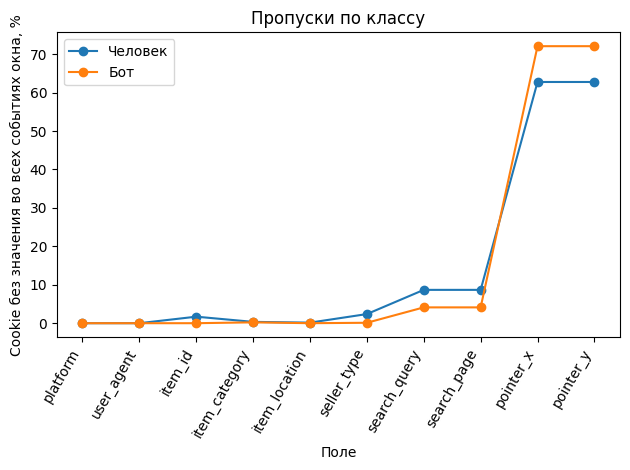

Cookie с событиями в окне по классам:
target
0    10192
1      899
Name: cookie_id, dtype: int64


In [ ]:
fields = ['platform', 'user_agent', 'item_id', 'item_category', 'item_location',
          'seller_type', 'search_query', 'search_page', 'pointer_x', 'pointer_y']

has_value = events_target.groupby(['cookie_id', 'target'])[fields].agg(
    lambda values: values.notna().any()
).reset_index()
has_value = train[['cookie_id', 'target']].merge(has_value, on=['cookie_id', 'target'], how='left')
has_value[fields] = has_value[fields].fillna(False)
missing_share = has_value.groupby('target')[fields].mean() * 100

for target, row in missing_share.iterrows():
    plt.plot(fields, 100 - row, marker='o', label='Бот' if target == 1 else 'Человек')

plt.xlabel('Поле')
plt.ylabel('Cookie без значения во всех событиях окна, %')
plt.title('Пропуски по классу')
plt.xticks(rotation=60, ha='right')
plt.legend()
plt.tight_layout()
plt.show()

print('Cookie с событиями в окне по классам:')
print(has_value.groupby('target')['cookie_id'].nunique())


## Модели CatBoost: baseline и итоговое решение

Сравним простую модель без подбора параметров с CatBoost, параметры которого выбираются по целевой метрике. Разбиение учитывает время: последние два дня train остаются финальной проверочной частью, а настройка идёт на более ранних днях. Test не используется ни для настройки, ни для оценки качества.

Для каждой куки считаем: интенсивность и разнообразие действий, отдельные типы событий и их доли, активность по часам, временные интервалы, платформу/User-Agent, поисковую страницу и наличие курсорных координат. В модель не передаём `cookie_id`, `target` или дату окна.

In [26]:
def browser_family(user_agent):
    """Свести длинную строку User-Agent к небольшому семейству браузера."""
    s = str(user_agent).lower()
    if s in ('nan', 'none', ''):
        return 'unknown'
    if 'yabrowser' in s:
        return 'yandex'
    if 'edg/' in s or 'edge/' in s:
        return 'edge'
    if 'opr/' in s or 'opera' in s:
        return 'opera'
    if 'firefox/' in s or 'fxios/' in s:
        return 'firefox'
    if 'chrome/' in s or 'crios/' in s:
        return 'chrome'
    if 'safari/' in s:
        return 'safari'
    return 'other'


In [ ]:
all_meta = pd.concat([
    train[['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']],
    test[['cookie_id', 'cookie_created_at', 'window_start_ts', 'window_end_ts']]
], ignore_index=True)

print('Всего кук:', len(all_meta))

Всего кук: 16000


In [28]:
ev_all = pd.concat([ev_train, ev_test], ignore_index=True)
ev_all['event_ts'] = pd.to_datetime(ev_all['event_ts'], errors='coerce')
ev_all = ev_all.sort_values(['cookie_id', 'event_ts'], kind='stable').reset_index(drop=True)

print('Всего событий:', len(ev_all))

Всего событий: 283833


In [29]:
features = all_meta[['cookie_id', 'cookie_created_at', 'window_start_ts']].copy()

features['cookie_age_days'] = (
    pd.to_datetime(features['window_start_ts'], errors='coerce')
    - pd.to_datetime(features['cookie_created_at'], errors='coerce')
).dt.total_seconds() / 86400

features = features[['cookie_id', 'cookie_age_days']]

In [ ]:
grouped = ev_all.groupby('cookie_id', sort=False, observed=True)

basic = grouped.agg(
    event_count=('event_name', 'size'),
    event_types=('event_name', 'nunique'),

    unique_items=('item_id', 'nunique'),
    unique_categories=('item_category', 'nunique'),
    unique_locations=('item_location', 'nunique'),
    unique_queries=('search_query', 'nunique'),

    first_event=('event_ts', 'min'),
    last_event=('event_ts', 'max'),

    seller_type_mode=(
        'seller_type',
        lambda x: (x.dropna().astype(str).mode().iloc[0] if x.notna().any()else 'unknown')),
        
    browser_mode=('user_agent', lambda x: (x.dropna().map(browser_family).mode().iloc[0] if x.notna().any() else 'unknown')))

In [31]:
basic['active_span_hours'] = (basic['last_event'] - basic['first_event']).dt.total_seconds() / 3600
basic = basic.drop(columns=['first_event', 'last_event'])

In [32]:
basic['items_per_category'] = (basic['unique_items'] / basic['unique_categories'].replace(0, 1))
basic['items_per_location'] = (basic['unique_items'] / basic['unique_locations'].replace(0, 1))
basic['categories_per_location'] = (basic['unique_categories'] / basic['unique_locations'].replace(0, 1))
basic['unique_items_per_event'] = (basic['unique_items'] / basic['event_count'].replace(0, 1))
basic['events_per_active_hour'] = (basic['event_count'] / basic['active_span_hours'].replace(0, 1))

In [ ]:
# Считаем интервалы между событиями и статистики движения курсора
ev_all = ev_all.sort_values(
    ['cookie_id', 'event_ts'],
    kind='stable'
).copy()

g = ev_all.groupby('cookie_id', sort=False)
ev_all['gap_minutes'] = g['event_ts'].diff().dt.total_seconds() / 60

# Распределение интервалов, первая строка каждой cookie без предыдущего события исключена автоматически
gap_stats = ev_all.groupby('cookie_id')['gap_minutes'].agg(
    mean_gap_minutes='mean',
    median_gap_minutes='median',
    min_gap_minutes='min',
    max_gap_minutes='max',
    std_gap_minutes='std',
)
basic = basic.join(gap_stats)

# Дополнительные признаки ритма: сессии, ночная активность и вариативность интервалов
session_start = ev_all['gap_minutes'].isna() | (ev_all['gap_minutes'] > 30)
n_sessions = session_start.groupby(ev_all['cookie_id']).sum().rename('n_sessions')
basic = basic.join(n_sessions)

ev_all['is_night'] = ev_all['event_ts'].dt.hour < 6
night_share = ev_all.groupby('cookie_id')['is_night'].mean().rename('night_share')
basic = basic.join(night_share)

iet_cv = (
    gap_stats['std_gap_minutes']
    / gap_stats['mean_gap_minutes'].replace(0, np.nan)
).rename('iet_cv')
basic = basic.join(iet_cv)

valid_gaps = ev_all.dropna(subset=['gap_minutes'])
zero_gap_share = (
    valid_gaps['gap_minutes'].eq(0)
    .groupby(valid_gaps['cookie_id'])
    .mean()
    .rename('zero_gap_share')
)
short_gap_share = (
    valid_gaps['gap_minutes'].lt(1)
    .groupby(valid_gaps['cookie_id'])
    .mean()
    .rename('short_gap_share')
)
basic = basic.join(zero_gap_share).join(short_gap_share)

# Движения курсора между соседними событиями, где координаты заполнены
pointer = ev_all.dropna(subset=['pointer_x', 'pointer_y']).copy()
pointer = pointer.sort_values(['cookie_id', 'event_ts'], kind='stable')
pointer['dx'] = pointer.groupby('cookie_id')['pointer_x'].diff()
pointer['dy'] = pointer.groupby('cookie_id')['pointer_y'].diff()
pointer['pointer_step'] = np.sqrt(pointer['dx'] ** 2 + pointer['dy'] ** 2)
pointer_stats = pointer.groupby('cookie_id')['pointer_step'].agg(
    pointer_step_mean='mean',
    pointer_step_std='std',
)
basic = basic.join(pointer_stats)


In [ ]:
# Счётчики действий, доли действий и отношения между основными типами событий
event_counts = pd.crosstab(ev_all['cookie_id'],ev_all['event_name'].fillna('unknown'))
event_counts.columns = ['event_' + str(name) for name in event_counts.columns]
event_shares = event_counts.div(event_counts.sum(axis=1).replace(0, 1), axis=0)
event_shares.columns = [c.replace('event_', 'share_', 1) for c in event_shares.columns]

view = event_counts.get('event_item_view', pd.Series(0, index=event_counts.index))
search = event_counts.get('event_search_results_view', pd.Series(0, index=event_counts.index))
photo = event_counts.get('event_photo_swipe', pd.Series(0, index=event_counts.index))
contact_cols = [c for c in event_counts.columns if c.startswith('event_contact_')]
contact = event_counts[contact_cols].sum(axis=1) if contact_cols else pd.Series(0, index=event_counts.index)

event_ratios = pd.DataFrame(index=event_counts.index)
event_ratios['view_search_ratio'] = view / search.replace(0, np.nan)
event_ratios['photo_per_view'] = photo / view.replace(0, np.nan)
event_ratios['contact_share'] = contact / event_counts.sum(axis=1).replace(0, 1)
basic = basic.join(event_ratios)


In [ ]:
# Доли платформ на cookie. Нормализуем регистр и пробелы
platform = ev_all['platform'].fillna('unknown').astype(str).str.lower().str.strip()
platform = platform.replace({'desktop': 'web'})
platform_counts = pd.crosstab(ev_all['cookie_id'], platform)
platform_shares = platform_counts.div(platform_counts.sum(axis=1).replace(0, 1), axis=0)
platform_shares.columns = ['platform_share_' + str(c) for c in platform_shares.columns]


In [ ]:
# Распределение событий по часам суток
ev_all['hour'] = ev_all['event_ts'].dt.hour
hour_counts = pd.crosstab(ev_all['cookie_id'], ev_all['hour']).reindex(columns=range(24), fill_value=0)
hour_counts.columns = [f'hour_{hour:02d}' for hour in hour_counts.columns]


In [ ]:
# Признаки поиска и наличия координат курсора
ev_all['search_page_num'] = pd.to_numeric(ev_all['search_page'], errors='coerce')
page_features = ev_all.groupby('cookie_id')['search_page_num'].agg(
    search_page_mean='mean',
    search_page_max='max',
)
pointer_share = (
    ev_all[['cookie_id', 'pointer_x', 'pointer_y']]
    .assign(has_pointer=lambda d: d[['pointer_x', 'pointer_y']].notna().any(axis=1))
    .groupby('cookie_id')['has_pointer']
    .mean()
    .rename('pointer_event_share')
)


In [ ]:
# Собираем все агрегаты в одну таблицу признаков
feats = basic.copy()
for feature_block in (event_counts, event_shares, platform_shares, hour_counts):
    feats = feats.join(feature_block, how='left')
feats = feats.join(page_features, how='left')
feats = feats.join(pointer_share, how='left')
feats = features.set_index('cookie_id').join(feats, how='left').reset_index()


In [ ]:
# Категориальные пропуски оставляем отдельной категорией, числовые пропуски/бесконечности заполняем нулём.
categorical = ['seller_type_mode', 'browser_mode']
for column in categorical:
    if column not in feats.columns:
        feats[column] = 'unknown'
    feats[column] = feats[column].fillna('unknown').astype(str)

numeric = feats.select_dtypes(include='number').columns
feats[numeric] = feats[numeric].replace([np.inf, -np.inf], np.nan).fillna(0)

assert feats['cookie_id'].is_unique
assert feats['cookie_id'].notna().all()
print('Размер feats:', feats.shape)
print('Пропусков:', int(feats.isna().sum().sum()))


Размер feats: (16000, 80)
Пропусков: 0


In [ ]:
train_features = train[['cookie_id', 'target']].merge(feats, on='cookie_id', how='left', validate='one_to_one')
test_features = test[['cookie_id']].merge(feats, on='cookie_id', how='left', validate='one_to_one')


In [ ]:
feature_cols = [c for c in train_features.columns if c not in ('cookie_id', 'target')]
print('Признаков в модели:', len(feature_cols))


Признаков в модели: 79


In [42]:
X = train_features[feature_cols].copy()
X_test = test_features[feature_cols].copy()
y = train_features['target'].astype(int).copy()

cat_features = ['seller_type_mode', 'browser_mode']
for col in cat_features:
    X[col] = X[col].fillna('unknown').astype(str)
    X_test[col] = X_test[col].fillna('unknown').astype(str)

numeric_cols = [c for c in feature_cols if c not in cat_features]
X[numeric_cols] = X[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)
X_test[numeric_cols] = X_test[numeric_cols].replace([np.inf, -np.inf], np.nan).fillna(0)

assert X.columns.equals(X_test.columns)
assert train_features['cookie_id'].equals(train['cookie_id'])
assert test_features['cookie_id'].equals(test['cookie_id'])


### Состав признаков

В модель входят агрегаты поведения внутри окна cookie: базовые счётчики и разнообразие действий, интервалы между событиями, сессии и курсорные движения, счётчики/доли событий, платформы, часы активности, поиск, заполненность курсора и возраст cookie. `cookie_id`, `target` и календарная дата окна в матрицу признаков не передаются.


In [ ]:
window_day = pd.to_datetime(train['window_start_ts']).dt.strftime('%Y-%m-%d')

all_days = sorted(window_day.unique())
holdout_days = all_days[-2:]
is_holdout = window_day.isin(holdout_days)

X_dev = X.loc[~is_holdout].reset_index(drop=True)
y_dev = y.loc[~is_holdout].reset_index(drop=True)
dev_days = window_day.loc[~is_holdout].reset_index(drop=True)

X_holdout = X.loc[is_holdout].reset_index(drop=True)
y_holdout = y.loc[is_holdout].reset_index(drop=True)

dev_unique_days = sorted(dev_days.unique())
fold_starts = [
    len(dev_unique_days) - 6,
    len(dev_unique_days) - 4,
    len(dev_unique_days) - 2,
]

folds = []
for start in fold_starts:
    valid_days_fold = dev_unique_days[start:start + 2]
    train_days_fold = dev_unique_days[:start]
    if len(valid_days_fold) == 2 and len(train_days_fold) >= 4:
        folds.append((train_days_fold, valid_days_fold))

assert len(folds) == 3, f'Получено временных фолдов: {len(folds)}'
print('Holdout-дни:', holdout_days)
print('Размеры dev , holdout:', len(X_dev), ',', len(X_holdout))

Holdout-дни: ['2026-04-18', '2026-04-19']
Размеры dev / holdout: 9853 / 1238


### Baseline: CatBoost без подбора

Сначала обучается одна модель с заранее зафиксированными стандартными параметрами. Она учится на ранних датах и оценивается на двух последних днях train. Для этой оценки не используется ранняя остановка по holdout, чтобы не подглядывать в проверочную часть.

In [45]:
def best_precision_recall_70(y_true, score):
    """Вернуть точный максимум Precision при Recall >= 0.70 из metric.py."""
    precision, recall = pr_curve(y_true, score)
    eligible = recall >= 0.70
    if not eligible.any():
        return 0.0, 0.0
    candidates = np.flatnonzero(eligible)
    best = candidates[np.argmax(precision[eligible])]
    return float(precision[best]), float(recall[best])


def print_metrics(name, y_true, score):
    p70, r_at_best = best_precision_recall_70(y_true, score)
    # Сверка с точной функцией задания.
    p70_official = precision_at_recall(y_true, score, recall=0.70)
    print(
        f'{name}: Precision@Recall>=70%={p70_official:.4f} '
        f'(Recall в выбранной точке={r_at_best:.3f}); '
        f'PR-AUC={average_precision_score(y_true, score):.4f}; '
        f'ROC-AUC={roc_auc_score(y_true, score):.4f}'
    )
    return p70_official, r_at_best

baseline_model = CatBoostClassifier(
    iterations=600,
    depth=6,
    learning_rate=0.05,
    l2_leaf_reg=5.0,
    loss_function='Logloss',
    eval_metric='AUC',
    random_seed=42,
    verbose=False,
    allow_writing_files=False,
    thread_count=-1
)
baseline_model.fit(X_dev, y_dev, cat_features=cat_features, verbose=False)
baseline_valid_score = baseline_model.predict_proba(X_holdout)[:, 1]
baseline_metrics = print_metrics('Baseline CatBoost', y_holdout, baseline_valid_score)

Baseline CatBoost: Precision@Recall>=70%=0.7765 (Recall в выбранной точке=0.702); PR-AUC=0.7529; ROC-AUC=0.9339


### Подбор Optuna по целевой метрике

Параметры выбираются по среднему `Precision@Recall>=70%` на трёх скользящих временных фолдах. Последние два дня остаются holdout и не участвуют в подборе.


In [ ]:
def objective(trial):
    params = {
        'iterations': trial.suggest_int('iterations', 250, 1000, step=50),
        'depth': trial.suggest_int('depth', 4, 8),
        'learning_rate': trial.suggest_float(
            'learning_rate', 0.015, 0.12, log=True
        ),
        'l2_leaf_reg': trial.suggest_float(
            'l2_leaf_reg', 1.0, 20.0, log=True
        ),
        'scale_pos_weight': trial.suggest_float(
            'scale_pos_weight', 0.7, 8.0, log=True
        ),
        'random_strength': trial.suggest_float(
            'random_strength', 0.0, 3.0
        ),
        'loss_function': 'Logloss',
        'eval_metric': 'AUC',
        'random_seed': 42,
        'verbose': False,
        'allow_writing_files': False,
        'thread_count': -1,
    }

    fold_scores = []

    for train_days_fold, valid_days_fold in folds:
        fold_train = dev_days.isin(train_days_fold).to_numpy()
        fold_valid = dev_days.isin(valid_days_fold).to_numpy()

        model = CatBoostClassifier(**params)
        model.fit(
            X_dev.iloc[fold_train],
            y_dev.iloc[fold_train],
            cat_features=cat_features,
            verbose=False,
        )

        score = model.predict_proba(X_dev.iloc[fold_valid])[:, 1]
        p_at_r70 = precision_at_recall(
            y_dev.iloc[fold_valid], score, recall=0.70
        )
        fold_scores.append(float(p_at_r70))

    if not fold_scores:
        raise ValueError('Не создано ни одного временного фолда')
    trial.set_user_attr('fold_scores', fold_scores)
    return float(np.mean(fold_scores))


study = optuna.create_study(
    direction='maximize',
    sampler=optuna.samplers.TPESampler(seed=42),
)
study.optimize(objective, n_trials=20)

print('Лучшее среднее P@R70 на временных фолдах:', study.best_value)
print('Лучшие параметры:', study.best_params)
print('P@R70 по фолдам:', study.best_trial.user_attrs['fold_scores'])


/Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
[I 2026-09-28 23:19:46,667] A new study created in memory with name: no-name-fe7f1394-08bd-4d6d-8f59-22daa811e202
[I 2026-09-28 23:20:03,408] Trial 0 finished with value: 0.6949982153851512 and parameters: {'iterations': 500, 'depth': 8, 'learning_rate': 0.06873020803429293, 'l2_leaf_reg': 6.009974718380312, 'scale_pos_weight': 1.023680675964654, 'random_strength': 0.46798356100860794}. Best is trial 0 with value: 0.6949982153851512.
[I 2026-09-28 23:20:09,986] Trial 1 finished with value: 0.6966990373967118 and parameters: {'iterations': 250, 'depth': 8, 'learning_rate': 0.052354281909450046, 'l2_leaf_reg': 8.341106432362084, 'scale_pos_weight': 0.7359973814761155, 'random_strength': 2.909729556485983}. B

Лучшее среднее P@R70 на временных фолдах: 0.7164432828686532
Лучшие параметры: {'iterations': 850, 'depth': 4, 'learning_rate': 0.030170375617106844, 'l2_leaf_reg': 1.7874969427272647, 'scale_pos_weight': 2.4687375503173836, 'random_strength': 1.6106042483837375}
P@R70 по фолдам: [0.8155339805825242, 0.6884057971014492, 0.6453900709219859]


### Сравнение на нетронутых последних днях

Переобучаем выбранную конфигурацию на всех датах до holdout фиксированным числом деревьев, полученным из временных проверок. Затем сравниваем её с baseline на тех же последних днях и по той же официальной метрике. Порог вручную не подбираем и в submission его не записываем.

In [47]:
best_params = {
    **study.best_params,
    'loss_function': 'Logloss',
    'eval_metric': 'AUC',
    'random_seed': 42,
    'verbose': False,
    'allow_writing_files': False,
    'thread_count': -1,
}

holdout_model = CatBoostClassifier(**best_params)
holdout_model.fit(X_dev, y_dev, cat_features=cat_features)

holdout_score = holdout_model.predict_proba(X_holdout)[:, 1]
final_metrics = print_metrics('Optuna CatBoost holdout', y_holdout, holdout_score)


Optuna CatBoost holdout: Precision@Recall>=70%=0.7128 (Recall в выбранной точке=0.713); PR-AUC=0.7409; ROC-AUC=0.9351


In [ ]:
final_model = CatBoostClassifier(**best_params)
final_model.fit(X, y, cat_features=cat_features)

test_score = final_model.predict_proba(X_test)[:, 1]
submission_catboost = pd.DataFrame({'cookie_id': test_features['cookie_id'], 'score': test_score,})

submission_path = Path('submission_catboost.csv')
submission_catboost.to_csv(submission_path, index=False)
print('Файл сохранён:', submission_path)

Файл сохранён: submission_catboost.csv


,importance
event_contact_message_sent,0.024363
event_contact_phone_show,0.033876
hour_16,0.038693
hour_05,0.059540
hour_08,0.071413
hour_20,0.075906
night_share,0.085764
hour_00,0.089388
event_contact_chat_open,0.094889
hour_11,0.098496


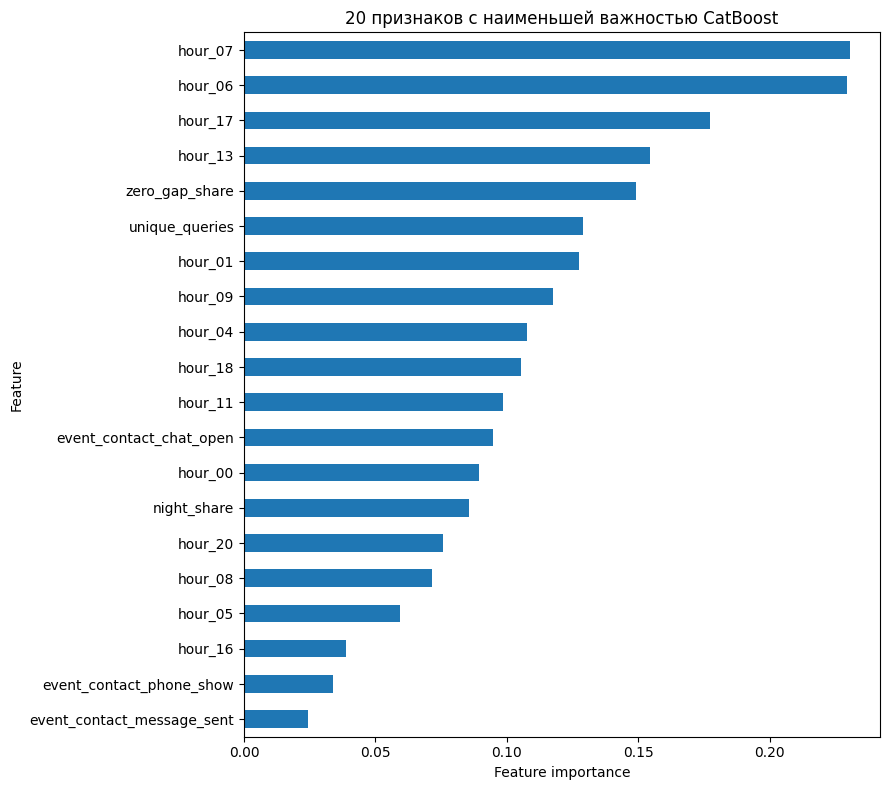

In [ ]:
importance = pd.Series(final_model.get_feature_importance(), index=X.columns,name='importance').sort_values()

display(importance.to_frame().head(20))

importance.head(20).plot(kind='barh', figsize=(9, 8))
plt.xlabel('Feature importance')
plt.ylabel('Feature')
plt.title('20 признаков с наименьшей важностью CatBoost')
plt.tight_layout()
plt.show()


### Интерпретация

`Precision@Recall>=70%` вычисляется точным кодом проекта, который объединяет одинаковые оценки в одну группу. Значение на holdout — локальная оценка будущего результата, но скрытая тестовая выборка может отличаться. Если ориентир не достигнут, не следует менять порог по отдельным test-cookie: улучшать нужно устойчивость признаков/модели по временным проверкам.

**Что получилось:** baseline обучается с фиксированными настройками; итоговая конфигурация выбирается на rolling time validation по основной метрике; сравнение проводится на более поздних днях, не использованных при выборе параметров; после этого итоговая модель обучается на полном train и записывает `submission_catboost.csv`.

In [52]:
print(f'Baseline P@R70: {baseline_metrics[0]:.4f}')
print(f'Итоговый P@R70: {final_metrics[0]:.4f}')
print(f'Изменение: {final_metrics[0] - baseline_metrics[0]:+.4f}')

Baseline P@R70: 0.7765
Итоговый P@R70: 0.7128
Изменение: -0.0637
